## Class 4: Curve Fitting

### Data Analysis and Regression
Tobias Rodriguez del Pozo, Summer 2026

#### Outline for Today

1. Review of Class 3.
2. Basis Functions: Polynomial, Splines, Gaussian Basis Functions.
3. Logistic Regression: Fitting a sigmoid curve to binary data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
plt.style.use("dark_background")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.15,
        "grid.linestyle": "--",
        "axes.edgecolor": "#444455",
        "axes.linewidth": 0.8,
        "figure.facecolor": "#1a1a2e",
        "axes.facecolor": "#16213e",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.framealpha": 0.3,
        "legend.fontsize": 10,
        "figure.figsize": (8, 5),
    }
)

### Motivation

Many times in finance, we are interested in fitting a curve to data. This could be for the purpose of:

- Interpolation: We know the 2-year and 10-year yields, and we want to know what the 5-year yield is.
- Extrapolation: We know the 2-year and 10-year yields, and we want to know what the 20-year yield is.
- De-noising: Similar to interpolation, but you can imagine that maybe we have 1000s of yield observations (eg. every US government bond yield) and we want to smooth out noisy market data.
- Dimensionality Reduction: We have 1000s of yields, and we want to see if we can represent them with a smaller number of parameters (eg. 3-5 parameters).

Many times, in a trading context, we are interested in trading the residual. For example, if we are able to come up with some smooth curve, any prices (yields) that deviate from that curve may be mispriced -- and could be indicative of a trade.

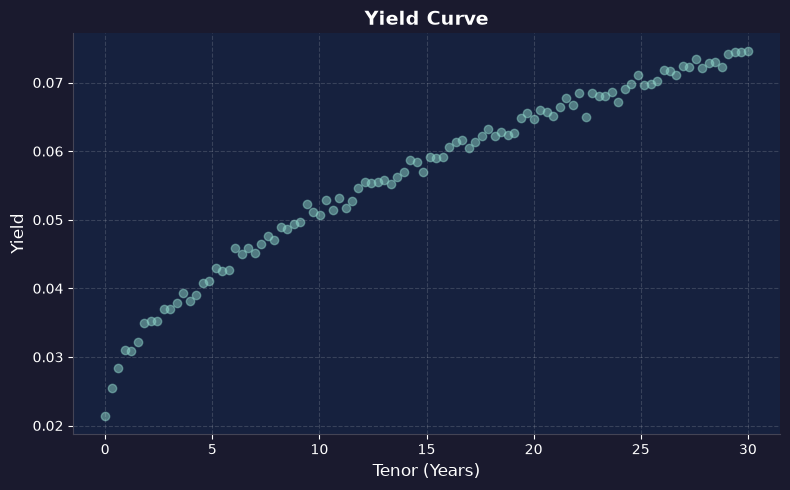

In [3]:
np.random.seed(42)

# Make some random tenors that are roughly upwards sloping (square-rooty)
tenors = np.linspace(0.01, 30, 100)
yields = 0.02 + 0.01 * np.sqrt(tenors) + 0.0009 * np.random.randn(len(tenors))

fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve")
fig.tight_layout()

### Basis Functions

To understand curve fitting, it might be most instructive to think about the problem in terms of basis functions. Formally, we have some complicated function, $f(x)$, and we want to "decompose" it into a linear combination of simpler functions, $\phi_i(x)$:

$$
f(x) = \sum_{i=1}^{n} w_i \phi_i(x)
$$

Where $w_i$ are the weights of each individual function. The additional constraint is that each $\phi_i(x)$ needs to be defined on the same domain as $f(x)$. Note that this does *not* mean each $\phi_i$ has to be non-zero everywhere -- most of the useful bases (splines, and the Gaussian blobs we're about to use) are deliberately local, and are essentially zero over most of the domain.

If you've seen any polynomial, then you've already seen basis functions! Eg;

$$
f(x) = 1 + 2x + 3x^2
$$

In this case, the basis functions would be $\phi_1(x) = 1$, $\phi_2(x) = x$, and $\phi_3(x) = x^2$. The weights would be $w_1 = 1$, $w_2 = 2$, and $w_3 = 3$.

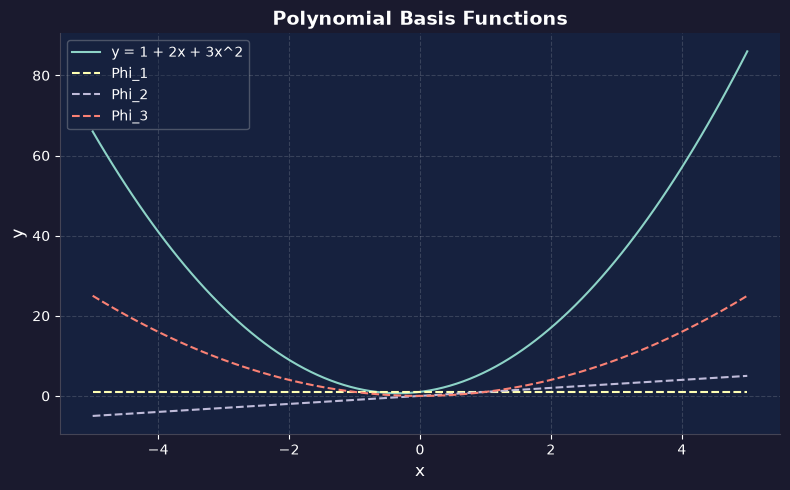

In [4]:
fig, ax = plt.subplots()
x = np.linspace(-5, 5, 100)
y = 1 + 2 * x + 3 * x**2

# Plot the y and then the basis functions
ax.plot(x, y, label="y = 1 + 2x + 3x^2")
ax.plot(x, [1] * len(x), label="Phi_1", linestyle="--")
ax.plot(x, x, label="Phi_2", linestyle="--")
ax.plot(x, x**2, label="Phi_3", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Polynomial Basis Functions")
ax.legend()
fig.tight_layout()

The *key* idea is that we can use basis functions to represent a complicated function as a linear combination of simpler functions. 

As another example, we might want to use Gaussian basis functions (we can think of these as just a series of normal distributions), eg.

$$
f(x) = \sum_{i=1}^{n} w_i \exp\left(-\frac{(x - \mu_i)^2}{2\sigma^2}\right)
$$

So we represent a function as a bunch of these little blobs.

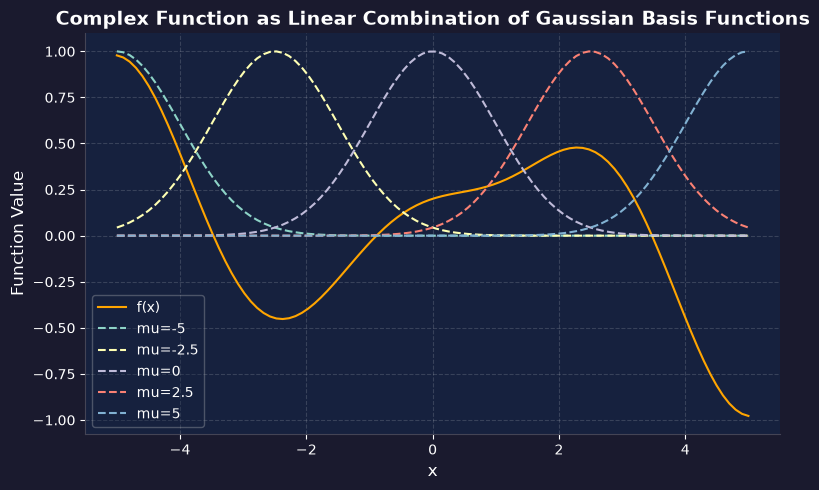

In [5]:
def gaussian_basis(x, mu, sigma):
    return np.exp(-((x - mu) ** 2) / (2 * sigma**2))


x = np.linspace(-5, 5, 100)
mus = [-5, -2.5, 0, 2.5, 5]
sigma = 1.0
ys = [gaussian_basis(x, mu, sigma) for mu in mus]
weights = [1, -0.5, 0.2, 0.5, -1]
complex_function = sum(w * y for w, y in zip(weights, ys))

fig, ax = plt.subplots()
ax.plot(x, complex_function, label="f(x)", color="orange")
for i, mu in enumerate(mus):
    ax.plot(x, ys[i], label=f"mu={mu}", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("Function Value")
ax.set_title("Complex Function as Linear Combination of Gaussian Basis Functions")
ax.legend()
fig.tight_layout()

Another example would be to use a spline, where really all a spline is is a piecewise polynomial, with some constraints to make sure that the pieces "fit together" nicely as we change $x$. 

For example, we might start with a piecewise quadratic, where we might have:
$$
f(x) =
\begin{cases}
1 + 2x + 3x^2 & \text{if } x < 0 \\
4 + 5x + 6x^2 & \text{if } x \geq 0
\end{cases}
$$



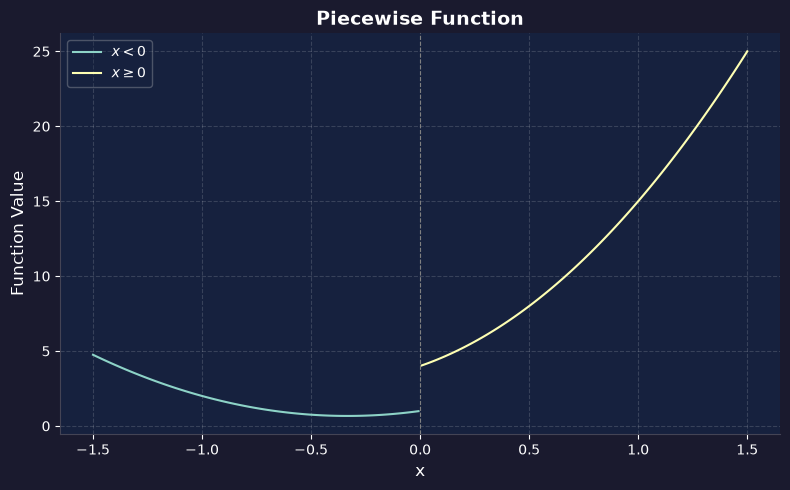

In [6]:
x = np.linspace(-1.5, 1.5, 200)
left, right = x < 0, x >= 0

fig, ax = plt.subplots()
ax.plot(x[left], 1 + 2 * x[left] + 3 * x[left] ** 2, label="$x < 0$")
ax.plot(x[right], 4 + 5 * x[right] + 6 * x[right] ** 2, label="$x \\geq 0$")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("Function Value")
ax.set_title("Piecewise Function")
ax.legend()
fig.tight_layout()

Obviously this has the problem that there's a discontinuity at $x=0$, so we might want to add a constraint that the two pieces have to be equal at $x=0$. A quadratic spline goes one step further and matches the *slope* at the knot as well, so we might have:
$$
f(x) =
\begin{cases}
1 + 2x + 3x^2 & \text{if } x < 0 \\
1 + 2x + 6x^2 & \text{if } x \geq 0
\end{cases}
$$
Where the core idea is that we have "knots" at certain points, which are where we switch from one polynomial to another (eg. at 0), and a degree-$k$ spline enforces that the function *and its first $k-1$ derivatives* are continuous at the knots. So a quadratic ($k=2$) spline matches values and first derivatives; the cubic splines you'll see used on real yield curves match second derivatives too, which is what keeps the forward curve smooth.

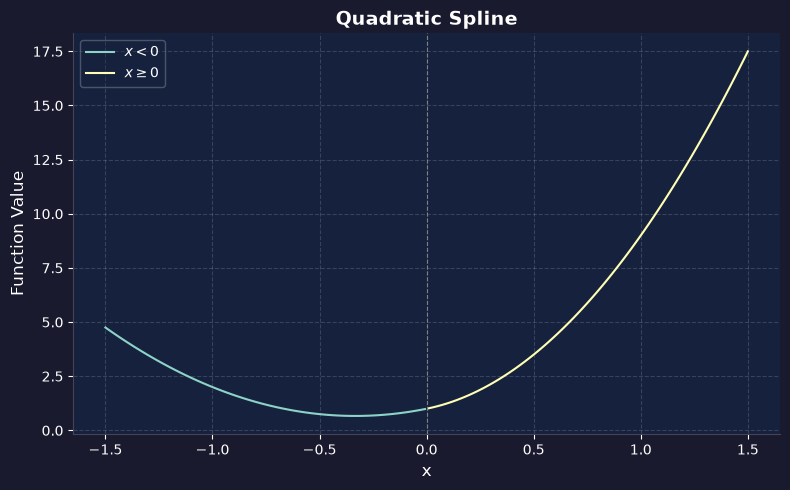

In [7]:
fig, ax = plt.subplots()
ax.plot(x[left], 1 + 2 * x[left] + 3 * x[left] ** 2, label="$x < 0$")
ax.plot(x[right], 1 + 2 * x[right] + 6 * x[right] ** 2, label="$x \\geq 0$")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("Function Value")
ax.set_title("Quadratic Spline")
ax.legend()
fig.tight_layout()

### Putting it Together

This problem should look *very* familiar to you, because it is exactly the same as OLS! In fact, all I did was change notation -- replacing my $\beta$ with $w$, and my $X$ with $\phi$. 

Therefore, given some basis functions, we can use OLS to fit a curve to real data. The only difference is that now instead of having different features, we have different basis functions (of the same feature). 

So, going back to our yield curve example...

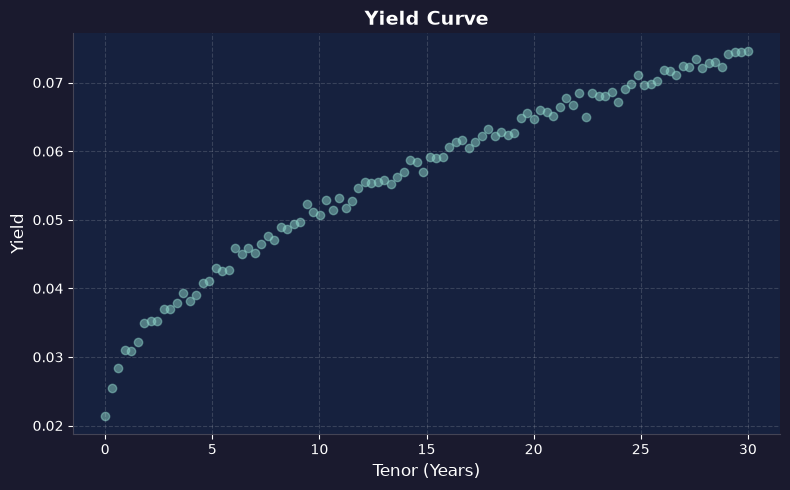

In [8]:
np.random.seed(42)

tenors = np.linspace(0.01, 30, 100)
yields = 0.02 + 0.01 * np.sqrt(tenors) + 0.0009 * np.random.randn(len(tenors))

fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve")
fig.tight_layout()

Lets suppose that I want to fit this with, say, 31 Gaussian blobs (one for each year). I can do this by creating 31 Gaussian basis functions, and then using OLS to fit the weights of each of those basis functions to the data.

In [9]:
blobs = 31
bfs = [gaussian_basis(tenors, mu, 1.0) for mu in np.linspace(0, 30, blobs)]

# Fit OLS
model = sm.OLS(yields, sm.add_constant(np.column_stack(bfs)))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     708.1
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           3.76e-74
Time:                        17:52:12   Log-Likelihood:                 579.92
No. Observations:                 100   AIC:                            -1096.
Df Residuals:                      68   BIC:                            -1012.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0187      0.016      1.142      0.257      -0.014       0.052
x1            -0.0049      0.014     -0.337      0.737      -0.034       0.024
x2             0.0135      0.004      3.470      0.001       0.006       0.021
x3            -0.0006      0.012     -0.046      0.963      -0.025       0.024
x4             0.0132      0.006      2.225      0.029       0.001       0.025
x5             0.0041      0.011      0.383      0.703      -0.017       0.025
x6             0.0105      0.007      1.492      0.140      -0.004       0.025
x7             0.0113      0.010      1.151      0.254      -0.008       0.031
x8             0.0086      0.008      1.114      0.269      -0.007       0.024
x9             0.0151      0.009      1.610      0.112      -0.004       0.034
x10            0.0071      0.008      0.889      0.377      -0.009       0.023
x11            0.0212      0.009      2.331      0.023       0.003       0.039
x12            0.0035      0.008      0.424      0.673      -0.013       0.020
x13            0.0243      0.009      2.717      0.008       0.006       0.042
x14            0.0058      0.008      0.696      0.489      -0.011       0.022
x15            0.0230      0.009      2.585      0.012       0.005       0.041
x16            0.0092      0.008      1.104      0.274      -0.007       0.026
x17            0.0222      0.009      2.495      0.015       0.004       0.040
x18            0.0121      0.008      1.446      0.153      -0.005       0.029
x19            0.0228      0.009      2.550      0.013       0.005       0.041
x20            0.0112      0.008      1.354      0.180      -0.005       0.028
x21            0.0257      0.009      2.825      0.006       0.008       0.044
x22            0.0119      0.008      1.487      0.142      -0.004       0.028
x23            0.0261      0.009      2.783      0.007       0.007       0.045
x24            0.0133      0.008      1.731      0.088      -0.002       0.029
x25            0.0253      0.010      2.569      0.012       0.006       0.045
x26            0.0151      0.007      2.155      0.035       0.001       0.029
x27            0.0273      0.011      2.553      0.013       0.006       0.049
x28            0.0122      0.006      2.076      0.042       0.000       0.024
x29            0.0355      0.012      2.903      0.005       0.011       0.060
x30            0.0011      0.004      0.290      0.772      -0.007       0.009
x31            0.0493      0.015      3.383      0.001       0.020       0.078
==============================================================================
Omnibus:                        2.442   Durbin-Watson:                   2.538
Prob(Omnibus):                  0.295   Jarque-Bera (JB):                2.169
Skew:                          -0.361   Prob(JB):                        0.338
Ku

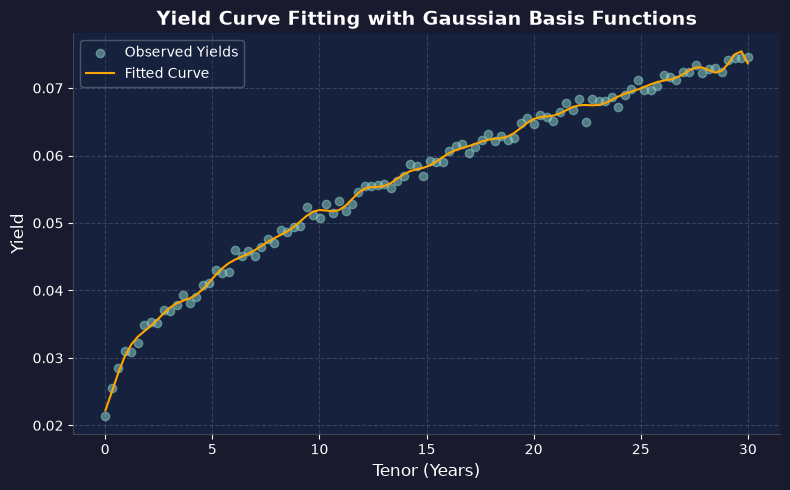

In [10]:
# Plot the fitted curve
fitted_yields = results.predict(sm.add_constant(np.column_stack(bfs)))
fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5, label="Observed Yields")
ax.plot(tenors, fitted_yields, color="orange", label="Fitted Curve")
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve Fitting with Gaussian Basis Functions")
ax.legend()
fig.tight_layout()

Uh oh! So my $r^2$ is 0.997 -- great. And the curve itself actually looks fine. But go back and look at the summary: the constant has a $t$-stat of 1.14 ($p = 0.26$), and about half of the individual coefficients are indistinguishable from zero. A great $r^2$ sitting on top of coefficients I can't trust is the classic signature of collinearity. Note that this doesn't wreck the fitted *curve* -- collinearity attacks the coefficients, not the predictions, which is exactly why the plot still looks fine -- but it does mean I can't read anything into any individual $w_i$, and a small change in the data would swing them around wildly. Specifically, I have 32 parameters (31 basis functions plus a constant) and only 100 data points.

And these blobs are badly collinear -- not "likely", provably. With $\sigma = 1$ and centers spaced 1 year apart, the 31 blobs sum to $\sqrt{2\pi} \approx 2.5066$ at *every* tenor between 5 and 25 years. They add up to a constant, which is exactly what my intercept already is: regressing the constant column on the 31 basis functions gives $r^2 = 0.99997$. So the design is nearly singular, which makes it much less stable...and then we need to worry about regularization (and another parameter), etc. One can see why it's easy to get into a hole. Specifically, with only 100 data points, I already have to answer:
- How many basis functions should I use?
- What basis functions should I use?
- If Gaussian, what width for each, what spacing between them?
- Do I need to regularize? If so, how much?

The solution here is typically to inject a strong prior belief about the shape of the curve. For example, we might believe that the yield curve should have 3 shapes, a level shape (up or down, parallel), a slope shape (front-minus-back), and a curvature shape (hump or dip). Therefore, we might want to use 3 basis functions that represent these shapes, and then fit the weights of those basis functions to the data.

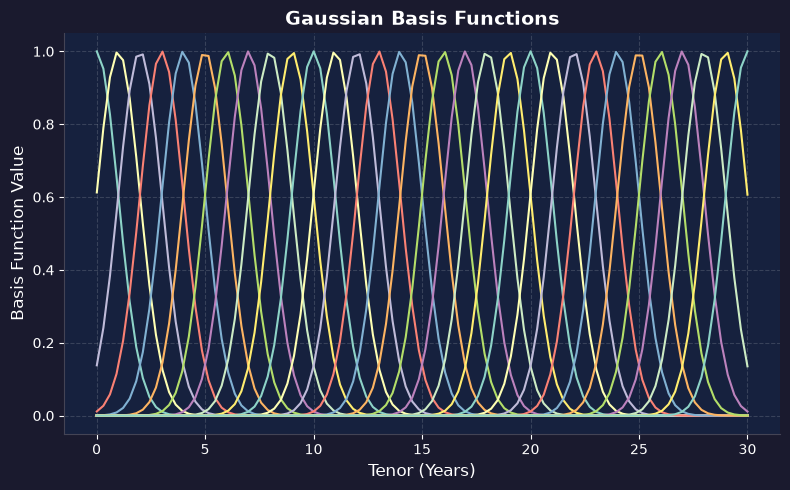

In [11]:
fig, ax = plt.subplots()
for i, mu in enumerate(np.linspace(0, 30, blobs)):
    ax.plot(tenors, bfs[i], label=f"BF {i + 1} (mu={mu:.2f})")
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Basis Function Value")
ax.set_title("Gaussian Basis Functions")
fig.tight_layout()

So the problem above wasn't that the blobs were too *sharp* -- with $\sigma = 1$ and centers 1 year apart they overlap heavily, which is exactly why they sum to a constant. But sharpness is its own failure mode. If I genuinely narrow them, so each blob is small relative to the spacing between centers, I get the other kind of bad:

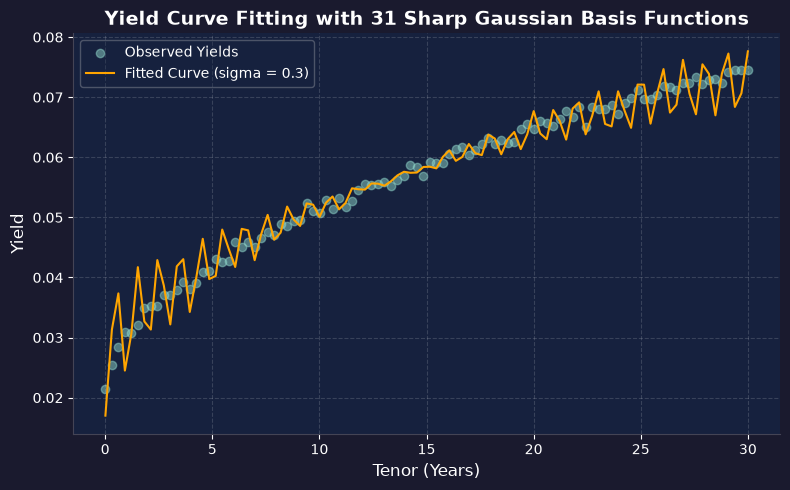

In [12]:
bfs_sharp = [gaussian_basis(tenors, mu, 0.3) for mu in np.linspace(0, 30, blobs)]
X_sharp = sm.add_constant(np.column_stack(bfs_sharp))
results_sharp = sm.OLS(yields, X_sharp).fit()

fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5, label="Observed Yields")
ax.plot(
    tenors,
    results_sharp.predict(X_sharp),
    color="orange",
    label="Fitted Curve (sigma = 0.3)",
)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve Fitting with 31 Sharp Gaussian Basis Functions")
ax.legend()
fig.tight_layout()

Each blob now only "sees" the handful of points nearest its center -- one year out, a $\sigma = 0.3$ blob has already decayed to 0.004, against 0.61 for the $\sigma = 1$ blobs -- so the curve spikes at the centers and dips in between instead of interpolating smoothly. Note that $r^2$ actually *fell*, to 0.944 -- sharpening the basis didn't even buy me a better in-sample fit, it just made the curve worse everywhere.

Yeah...not great. So, what can we do? Well, one thing that might help would be to have fewer, broader shapes. For example, instead of having 31 blobs, maybe we go with 5 blobs that are broader.

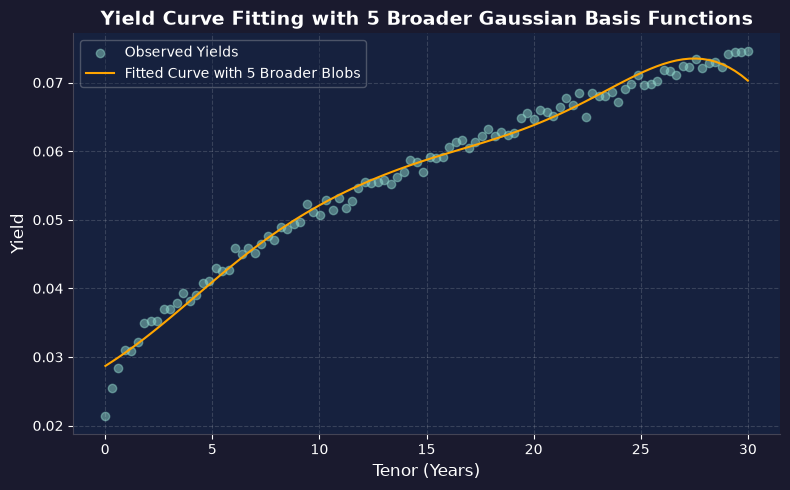

In [13]:
blobs = 5
bfs = [gaussian_basis(tenors, mu, 5.0) for mu in np.linspace(0, 30, blobs)]

model = sm.OLS(yields, sm.add_constant(np.column_stack(bfs)))
results = model.fit()

fitted_yields = results.predict(sm.add_constant(np.column_stack(bfs)))
fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5, label="Observed Yields")
ax.plot(
    tenors, fitted_yields, color="orange", label="Fitted Curve with 5 Broader Blobs"
)
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve Fitting with 5 Broader Gaussian Basis Functions")
ax.legend()
fig.tight_layout()

Still not great! But let's run with this example. One additional thing we might want to do is add some weighting. Remember when I said in Class 3 that we can use WLS to inject a belief about what we think is important? 

Well, typically the most liquid bonds are the 2-year, 5-year, and 10-year bonds. Therefore, we might want to have both *unevenly* spaced basis functions (to target those points), and also weight those points more heavily in the regression.

For example, define our basis function centers to be at 0, 2, 5, 10, and 30 years. Then, run WLS where the weights exponentially decay as we move away from those points. This gives us a final functional form that looks like this:

$$
f(x) = w_0 + \sum_{i=1}^{5} w_i \exp\left(-\frac{(x - \mu_i)^2}{2\sigma^2}\right) \quad \text{with } \mu = [0, 2, 5, 10, 30] \text{ and } \sigma = 5
$$

And

$$
\hat{w} = \arg\min_w \sum_{i=1}^{n} v_i (y_i - f(x_i))^2 \quad \text{with } v_i = \exp\left(-\frac{(x_i - \mu_j)^2}{2\sigma^2}\right) \text{ for the closest } \mu_j
$$

Careful with the two sets of weights here: the $w_i$ are what we're solving for (one per basis function), while the $v_i$ are fixed numbers we pick up front (one per *data point*) that say how much we care about fitting each observation.

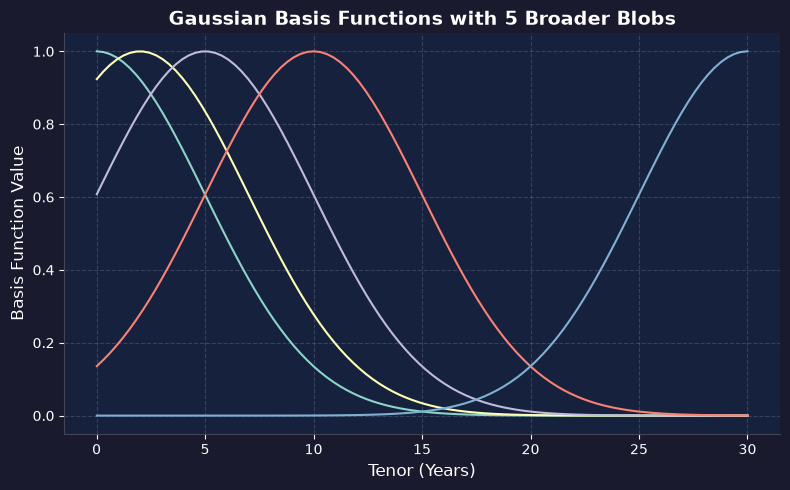

In [14]:
# Define the raw basis functions
basis_points = [0, 2, 5, 10, 30]
basis_functions = [gaussian_basis(tenors, mu, 5.0) for mu in basis_points]

# Weight each data point by its distance to the *closest* center
v_i = np.max(
    np.exp(-((tenors[:, None] - np.array(basis_points)) ** 2) / (2 * 5.0**2)), axis=1
)

# Plot the basis functions
fig, ax = plt.subplots()
for i, mu in enumerate(basis_points):
    ax.plot(tenors, basis_functions[i], label=f"BF {i + 1} (mu={mu})")
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Basis Function Value")
ax.set_title("Gaussian Basis Functions with 5 Broader Blobs")
fig.tight_layout()

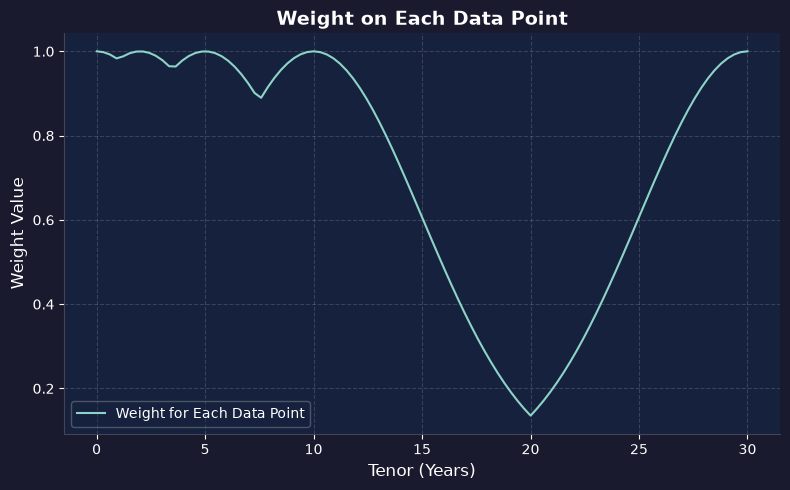

In [15]:
# Plot the weights of the data points in the regression
fig, ax = plt.subplots()
ax.plot(tenors, v_i, label="Weight for Each Data Point")
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Weight Value")
ax.set_title("Weight on Each Data Point")
ax.legend()
fig.tight_layout()

In [16]:
# Now fit WLS
model_wls = sm.WLS(
    yields, sm.add_constant(np.column_stack(basis_functions)), weights=v_i
)
results_wls = model_wls.fit()
results_wls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.994
Model:                            WLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2927.
Date:                Mon, 10 Aug 2026   Prob (F-statistic):          1.69e-101
Time:                        17:52:13   Log-Likelihood:                 530.63
No. Observations:                 100   AIC:                            -1049.
Df Residuals:                      94   BIC:                            -1034.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0633      0.001     98.111      0.000       0.062       0.065
x1            -0.1151      0.009    -12.937      0.000      -0.133      -0.097
x2             0.1147      0.014      8.422      0.000       0.088       0.142
x3            -0.0460      0.007     -6.888      0.000      -0.059      -0.033
x4            -0.0009      0.002     -0.458      0.648      -0.005       0.003
x5             0.0108      0.001     13.078      0.000       0.009       0.012
==============================================================================
Omnibus:                       26.052   Durbin-Watson:                   1.153
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               85.717
Skew:                          -0.787   Prob(JB):                     2.44e-19
Kurtosis:                       7.254   Cond. No.                         205.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

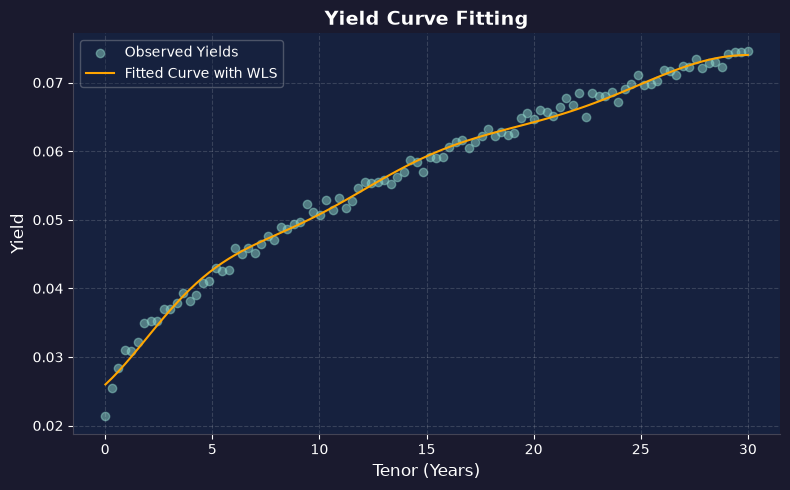

In [17]:
fitted_yields_wls = results_wls.predict(
    sm.add_constant(np.column_stack(basis_functions))
)
fig, ax = plt.subplots()
ax.scatter(tenors, yields, alpha=0.5, label="Observed Yields")
ax.plot(tenors, fitted_yields_wls, color="orange", label="Fitted Curve with WLS")
ax.set_xlabel("Tenor (Years)")
ax.set_ylabel("Yield")
ax.set_title("Yield Curve Fitting")
ax.legend()
fig.tight_layout()

Somewhat better, but one thing that's not very intuitive is that we have a negative $w$ for some of the basis functions. So -- we should maybe run non-negative least squares ($\beta \geq 0$), or maybe we need to regularize, or maybe we need to change the basis functions, or, or, or or.

Hopefully at this point you see how rich this problem is.

Also, evaluating a curve-fit is hard, typically one uses RMSE, and also $r^2$, but really what matters is how predictive the curve is out-of-sample.

### Logistic Regression

Motivation: What happens if I have binary data?

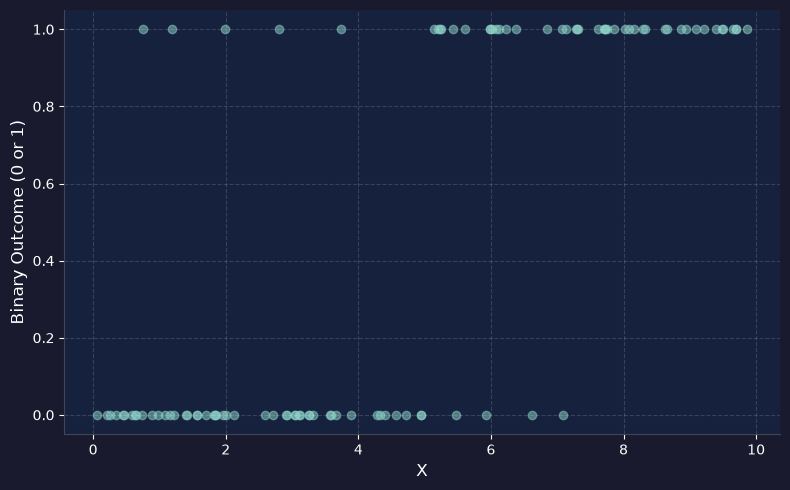

In [18]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10
y = (X.flatten() > 5).astype(int)
# Add random noise to the binary outcome
y = np.where(np.random.rand(100) < 0.1, 1 - y, y)

# Plot the data
fig, ax = plt.subplots()
ax.scatter(X, y, alpha=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Binary Outcome (0 or 1)")
fig.tight_layout()

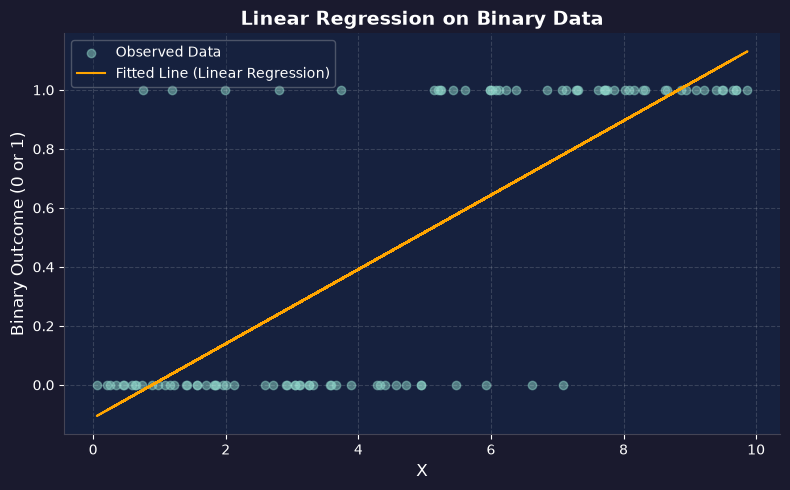

In [19]:
# Fit linear regression
model_lr = sm.OLS(y, sm.add_constant(X))
results_lr = model_lr.fit()

# Plot the fitted line
fitted_y_lr = results_lr.predict(sm.add_constant(X))
fig, ax = plt.subplots()
ax.scatter(X, y, alpha=0.5, label="Observed Data")
ax.plot(X, fitted_y_lr, color="orange", label="Fitted Line (Linear Regression)")
ax.set_xlabel("X")
ax.set_ylabel("Binary Outcome (0 or 1)")
ax.set_title("Linear Regression on Binary Data")
ax.legend()
fig.tight_layout()

Okay, well this is obviously atrocious. I have binary data (either 0 or 1), and yet somehow my model is predicting negative values, and values greater than 1. This is clearly a misspecified model!

The question now becomes, given a binary outcome, how can we try to predict it? Well, this is where logistic regression comes in. The idea is that instead of:
$$
y = \beta_0 + \beta_1 x + \epsilon
$$
We instead use a logistic function to constrain the output to be between 0 and 1. Note that what we model is the *probability* that $y$ is 1, not $y$ itself -- $y$ is always exactly 0 or 1.
$$
P(y = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}, \qquad y \mid x \sim \text{Bernoulli}\big(P(y = 1 \mid x)\big)
$$

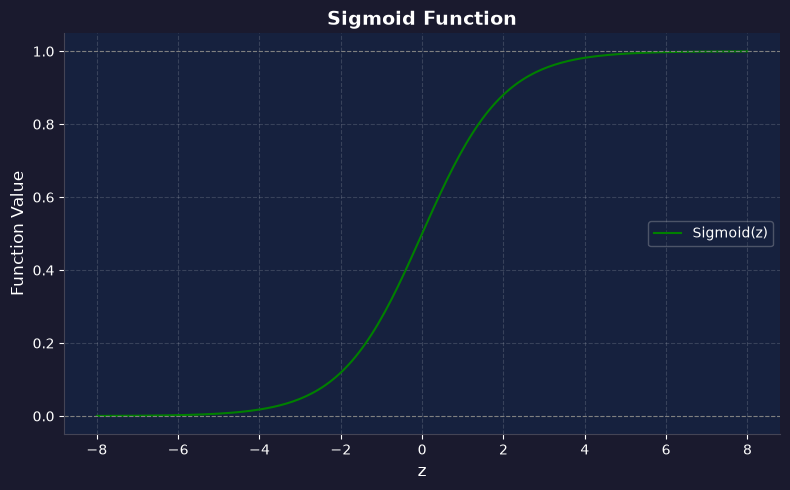

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 200)

fig, ax = plt.subplots()
ax.plot(z, sigmoid(z), color="green", label="Sigmoid(z)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("z")
ax.set_ylabel("Function Value")
ax.set_title("Sigmoid Function")
ax.legend()
fig.tight_layout()

So the sigmoid takes our linear regression $\beta_0 + \beta_1 x$, which can be any number, and then forces it to be between 0 and 1.

One thing to notice is that we can't just take a sigmoid transform and then fit regular OLS -- the sigmoid is a non-linear function. Instead, we pick the $\beta$ that makes the observed 0s and 1s most likely -- maximum likelihood, maximizing

$$
\ell(\beta) = \sum_{i=1}^{n} \Big[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \Big], \qquad p_i = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_i)}}
$$
which has no closed form

In [21]:
logit_model = sm.Logit(y, sm.add_constant(X))
logit_results = logit_model.fit()
logit_results.summary()

Optimization terminated successfully.
         Current function value: 0.341906
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Aug 2026   Pseudo R-squ.:                  0.5062
Time:                        17:52:13   Log-Likelihood:                -34.191
converged:                       True   LL-Null:                       -69.235
Covariance Type:            nonrobust   LLR p-value:                 5.671e-17
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2243      0.818     -5.162      0.000      -5.828      -2.620
x1             0.8732      0.159      5.485      0.000       0.561       1.185
==============================================================================
"""

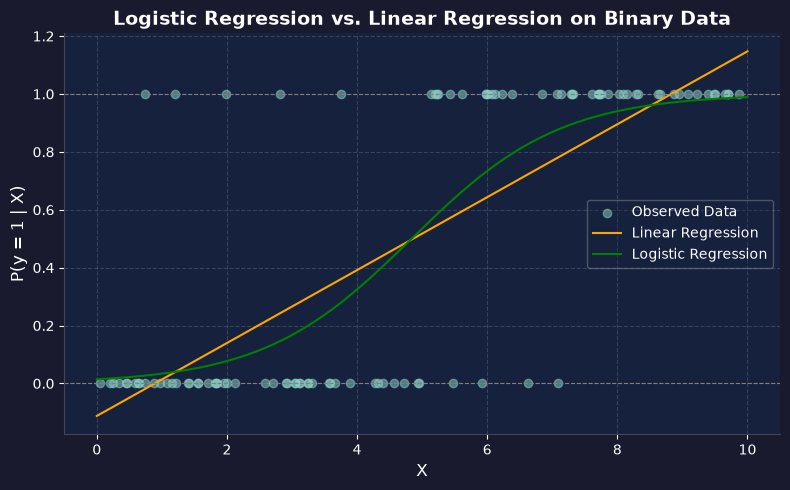

In [22]:
# Predict on a sorted grid -- X itself is unsorted, which would zig-zag the line
grid = np.linspace(0, 10, 200)

fig, ax = plt.subplots()
ax.scatter(X, y, alpha=0.5, label="Observed Data")
ax.plot(
    grid,
    results_lr.predict(sm.add_constant(grid)),
    color="orange",
    label="Linear Regression",
)
ax.plot(
    grid,
    logit_results.predict(sm.add_constant(grid)),
    color="green",
    label="Logistic Regression",
)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("X")
ax.set_ylabel("P(y = 1 | X)")
ax.set_title("Logistic Regression vs. Linear Regression on Binary Data")
ax.legend()
fig.tight_layout()

Much better.

The coefficients are a little less interpretable, but the units are *log-odds*. So $\beta_1 = 0.873$ means every extra unit of $x$ multiplies the odds of $y = 1$ by $e^{0.873} \approx 2.4$. And the fitted line crosses 50% at $-\beta_0 / \beta_1 = 4.84$, which is right about where we put the true threshold (5) when we made the data.

#### Conclusion

To recap, curve fitting is really just OLS wearing a different hat. We swapped $X$ with basis functions $\phi(x)$ and our $\beta$ with weights $w$.

The hard part is designing basis functions and features that make sense for the problem at hand.

Finally, we saw that OLS is not appropriate for binary data.

#### Next Class

1. PCA
2. Boosting and Bagging
3. Tree-based methods and Random Forests
4. Clustering